In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation

df = pd.read_csv('../data/features_with_predictions.csv')

fig, ax = plt.subplots(figsize=(12, 6))

def animate(i):
    ax.clear()
    row = df.iloc[i]
    
    # color bars by size
    colors = ['red' if row['anomaly'] == -1 else 'steelblue' 
              for _, row in df.iloc[:i+1].iterrows()]
    
    ax.bar(df['year'].iloc[:i+1], df['area_km2'].iloc[:i+1], 
           color=colors, alpha=0.85, edgecolor='white', linewidth=0.5)
    
    ax.axhline(df['area_km2'].mean(), color='orange', linestyle='--', 
               linewidth=1.5, label=f"40yr mean: {df['area_km2'].mean():.0f} km²")
    ax.axhline(1900*2.59, color='green', linestyle=':', 
               linewidth=1.5, label='Task Force target: 4,921 km²')
    
    ax.set_xlim(1984, 2025)
    ax.set_ylim(0, 26000)
    ax.set_xlabel('Year', fontsize=12)
    ax.set_ylabel('Dead Zone Area (km²)', fontsize=12)
    ax.set_title(f'Gulf of Mexico Dead Zone — {int(df["year"].iloc[i])}  |  {int(df["area_km2"].iloc[i]):,} km²', 
                 fontsize=14, fontweight='bold')
    ax.legend(loc='upper left', fontsize=9)
    
    # annotate record year
    if df['year'].iloc[i] == 2017:
        ax.annotate('RECORD', xy=(2017, 22720), xytext=(2010, 24000),
                    fontsize=10, color='red', fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color='red'))

ani = animation.FuncAnimation(fig, animate, frames=len(df), 
                               interval=300, repeat=False)

ani.save('../outputs/deadzone_animation.gif', writer='pillow', fps=4, dpi=120)
plt.close()
print("Animation saved to outputs/deadzone_animation.gif")

Animation saved to outputs/deadzone_animation.gif


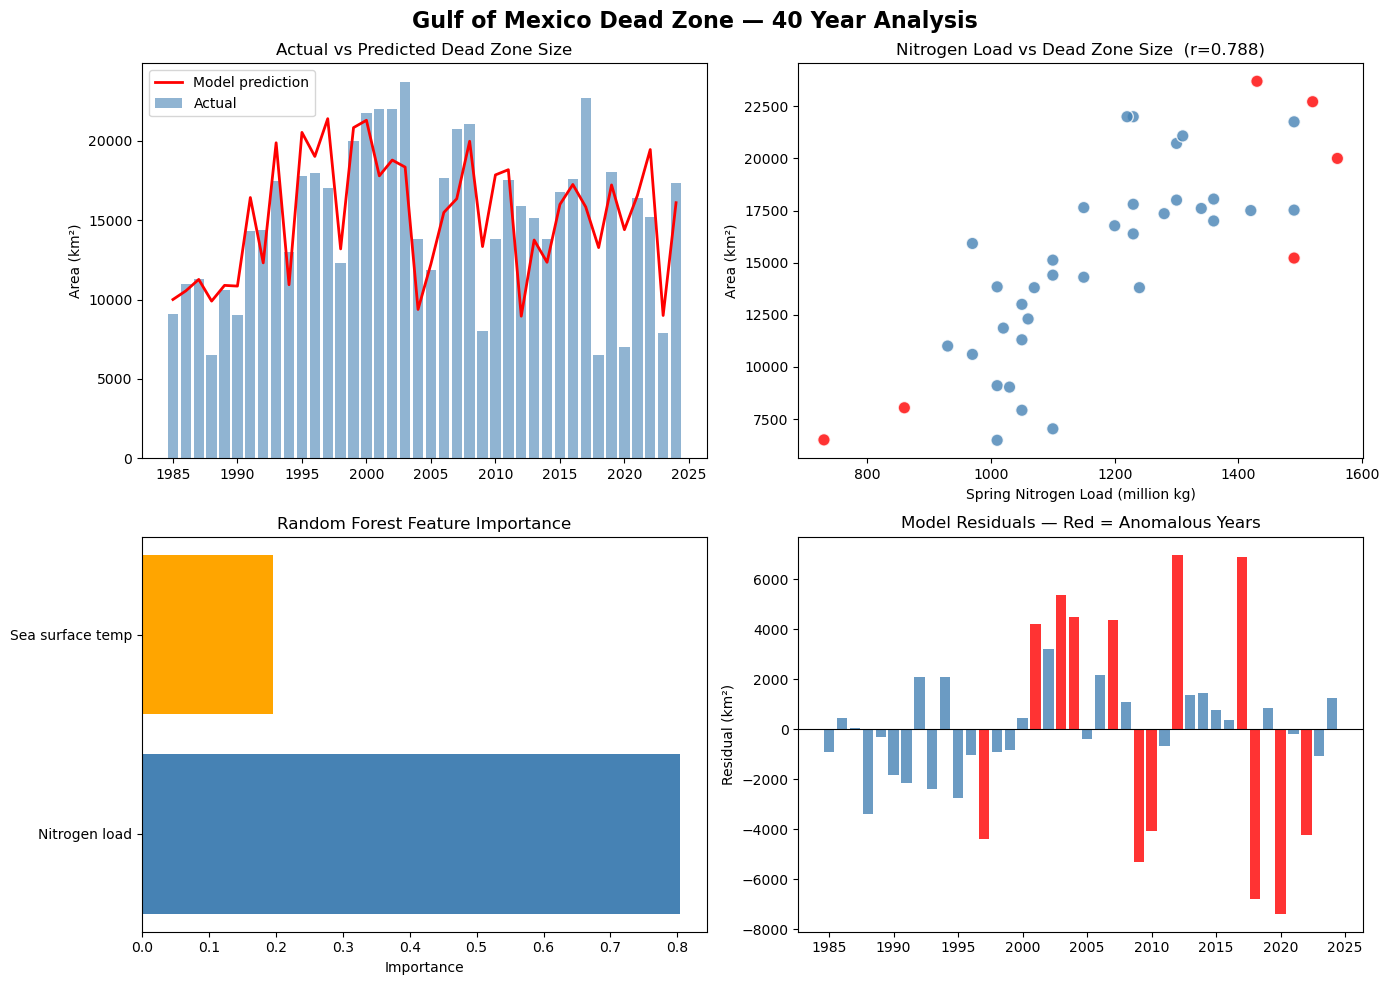

Dashboard saved.


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Gulf of Mexico Dead Zone — 40 Year Analysis', fontsize=16, fontweight='bold')

# top left: timeseries with prediction overlay
axes[0,0].bar(df['year'], df['area_km2'], color='steelblue', alpha=0.6, label='Actual')
axes[0,0].plot(df['year'], df['predicted'], color='red', linewidth=2, label='Model prediction')
axes[0,0].set_title('Actual vs Predicted Dead Zone Size')
axes[0,0].set_ylabel('Area (km²)')
axes[0,0].legend()

# top right: nitrogen vs dead zone scatter
colors = df['anomaly'].map({1: 'steelblue', -1: 'red'})
axes[0,1].scatter(df['nitrogen_load'], df['area_km2'], c=colors, s=80, alpha=0.8, edgecolors='white')
axes[0,1].set_title('Nitrogen Load vs Dead Zone Size  (r=0.788)')
axes[0,1].set_xlabel('Spring Nitrogen Load (million kg)')
axes[0,1].set_ylabel('Area (km²)')

# bottom left: feature importance
importances = pd.Series([0.804, 0.196], index=['Nitrogen load', 'Sea surface temp'])
axes[1,0].barh(importances.index, importances.values, color=['steelblue', 'orange'])
axes[1,0].set_title('Random Forest Feature Importance')
axes[1,0].set_xlabel('Importance')

# bottom right: residuals
colors_r = ['red' if abs(r) > 4000 else 'steelblue' for r in df['residual']]
axes[1,1].bar(df['year'], df['residual'], color=colors_r, alpha=0.8)
axes[1,1].axhline(0, color='black', linewidth=0.8)
axes[1,1].set_title('Model Residuals — Red = Anomalous Years')
axes[1,1].set_ylabel('Residual (km²)')

plt.tight_layout()
plt.savefig('../outputs/summary_dashboard.png', dpi=150)
plt.show()
print("Dashboard saved.")

In [4]:
import os
outputs = os.listdir('../outputs/')
print('\n'.join(outputs))

.ipynb_checkpoints
anomaly_detection.png
deadzone_animation.gif
deadzone_timeseries.png
gulf_oxygen_surface.png
model_results.png
nitrogen_vs_deadzone.png
summary_dashboard.png


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np

df = pd.read_csv('../data/features_with_predictions.csv')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor('#ffffff')
plt.subplots_adjust(wspace=0.35, top=0.88)

def animate(i):
    ax1, ax2 = axes
    ax1.clear()
    ax2.clear()

    current = df.iloc[:i+1]
    year = int(df.iloc[i]['year'])

    # color current year differently
    colors_n = ['#1a6b8a' if j < i else '#e8a030' for j in range(i+1)]
    colors_d = ['#2a7a3a' if j < i else '#c0392b' for j in range(i+1)]

    # left — nitrogen load
    ax1.bar(current['year'], current['nitrogen_load'],
            color=colors_n, width=0.7, edgecolor='none')
    ax1.set_xlim(1984, 2025)
    ax1.set_ylim(0, 1800)
    ax1.set_title('Spring Nitrogen Load', fontsize=12, fontweight='600',
                  fontfamily='sans-serif', pad=10, color='#1a1a18')
    ax1.set_ylabel('Million kg', fontsize=10, color='#666')
    ax1.set_xlabel('Year', fontsize=10, color='#666')
    ax1.tick_params(colors='#888', labelsize=9)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.spines['left'].set_color('#eee')
    ax1.spines['bottom'].set_color('#eee')
    ax1.set_facecolor('white')
    ax1.yaxis.grid(True, color='#f0f0f0', linewidth=0.8)
    ax1.set_axisbelow(True)

    # annotate current year value
    ax1.annotate(f"{int(df.iloc[i]['nitrogen_load'])} M kg",
                 xy=(year, df.iloc[i]['nitrogen_load']),
                 xytext=(0, 6), textcoords='offset points',
                 ha='center', fontsize=8, color='#e8a030', fontweight='600')

    # right — dead zone area
    ax2.bar(current['year'], current['area_km2'],
            color=colors_d, width=0.7, edgecolor='none')
    ax2.set_xlim(1984, 2025)
    ax2.set_ylim(0, 26000)
    ax2.set_title('Dead Zone Area', fontsize=12, fontweight='600',
                  fontfamily='sans-serif', pad=10, color='#1a1a18')
    ax2.set_ylabel('km²', fontsize=10, color='#666')
    ax2.set_xlabel('Year', fontsize=10, color='#666')
    ax2.tick_params(colors='#888', labelsize=9)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.spines['left'].set_color('#eee')
    ax2.spines['bottom'].set_color('#eee')
    ax2.set_facecolor('white')
    ax2.yaxis.grid(True, color='#f0f0f0', linewidth=0.8)
    ax2.set_axisbelow(True)

    # mean line
    ax2.axhline(df['area_km2'].mean(), color='#aaa', linewidth=1,
                linestyle='--', label='40yr mean')

    # annotate current year value
    ax2.annotate(f"{int(df.iloc[i]['area_km2']):,} km²",
                 xy=(year, df.iloc[i]['area_km2']),
                 xytext=(0, 6), textcoords='offset points',
                 ha='center', fontsize=8, color='#c0392b', fontweight='600')

    # year label in center
    fig.suptitle(str(year), fontsize=22, fontweight='700',
                 color='#1a1a18', fontfamily='sans-serif', y=0.98)

ani = animation.FuncAnimation(fig, animate, frames=len(df),
                               interval=350, repeat=False)

ani.save('../outputs/deadzone_animation_v2.gif', writer='pillow', fps=3, dpi=140)
plt.close()
print("Saved to outputs/deadzone_animation_v2.gif")

Saved to outputs/deadzone_animation_v2.gif
